In [1]:
import pandas as pd 
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn import svm
from sklearn import tree
from yellowbrick.classifier import ROCAUC

In [2]:
data=pd.read_csv("balanced_glass_rand.csv")

In [3]:
data

,Unnamed: 0,Class,b,c,d,e,f,g,h,i,j
0,0,2,1.52777,12.64,0.00,0.67,72.02,0.06,14.40,0.00,0.00
1,1,1,1.51743,13.30,3.60,1.14,73.09,0.58,8.17,0.00,0.00
2,2,6,1.51556,13.87,0.00,2.54,73.23,0.14,9.41,0.81,0.01
3,3,2,1.52475,11.45,0.00,1.88,72.19,0.81,13.24,0.00,0.34
4,4,2,1.51829,13.24,3.90,1.41,72.33,0.55,8.31,0.00,0.10
...,...,...,...,...,...,...,...,...,...,...,...
253,253,2,1.51667,12.94,3.61,1.26,72.75,0.56,8.60,0.00,0.00
254,254,1,1.51808,13.43,2.87,1.19,72.84,0.55,9.03,0.00,0.00
255,255,5,1.51905,14.00,2.39,1.56,72.37,0.00,9.57,0.00,0.00
256,256,3,1.51610,13.33,3.53,1.34,72.67,0.56,8.33,0.00,0.00


In [4]:
data.columns=['id','Class','b','c','d','e','f','g','h','i','j']

In [5]:
data.set_index("id", inplace=True)

In [6]:
df1 = data[['Class']]

In [7]:
df1

,Class
id,
0,2
1,1
2,6
3,2
4,2
...,...
253,2
254,1
255,5


In [8]:
df2 = data[['b','c','d','e','f','g','h','i','j']]

In [9]:
data_class=data.Class

In [10]:
data_class

id
0      2
1      1
2      6
3      2
4      2
      ..
253    2
254    1
255    5
256    3
257    2
Name: Class, Length: 258, dtype: int64

In [11]:
X = OrdinalEncoder().fit_transform(df2)
y = LabelEncoder().fit_transform(data_class)

In [12]:
#X

In [13]:
#y

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [15]:
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=6)
knn = KNeighborsClassifier(n_neighbors=5)

In [16]:
my_title = "ROCAUC Curves for DecisionTreeClassifier on winequality_red"
#title=my_title

In [17]:
visualizer = ROCAUC(model, classes=["1", "2", "3", "4", "5", "6"])
visualizer_1 = ROCAUC(clf, classes=["1", "2", "3", "4", "5", "6"], title=my_title)
visualizer_2 = ROCAUC(knn, classes=["1", "2", "3", "4", "5", "6"])

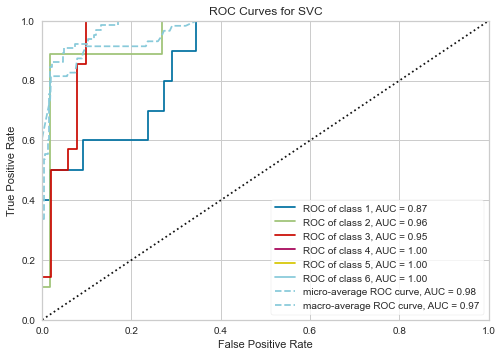

<AxesSubplot:title={'center':'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [18]:
visualizer.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()        

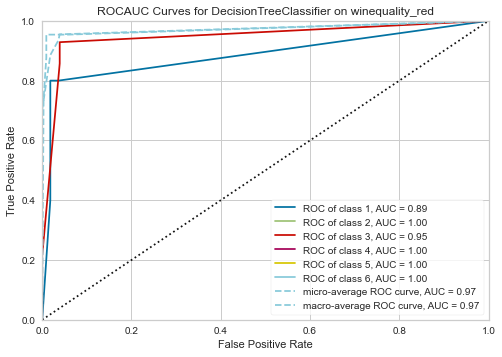

<AxesSubplot:title={'center':'ROCAUC Curves for DecisionTreeClassifier on winequality_red'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [19]:
visualizer_1.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_1.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_1.show()        

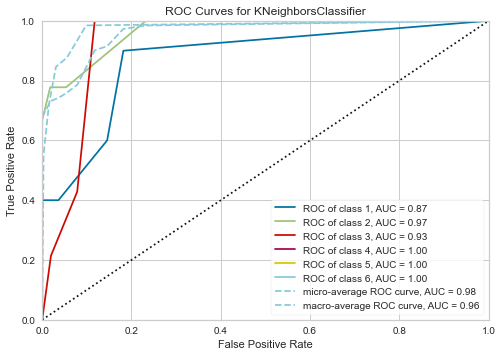

<AxesSubplot:title={'center':'ROC Curves for KNeighborsClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [20]:
visualizer_2.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer_2.score(X_test, y_test)        # Evaluate the model on the test data
visualizer_2.show()    